<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Malaria%20Prediction(Logistic%20Regression%2C%20optimized%20with%20Stochastic%20Gradient%20Descent%20(SGD)%2C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,auc

In [10]:
#LOad the dataset
df = pd.read_csv("Malaria_Dataset.csv")
df.head()

,IP_Number,Age,Sex,Residence_Area,DOA,Discharge_Date,Fever,Headache,Abdominal_Pain,General_Body_Malaise,...,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Primary_Code,Diagnosis_Type,Target,Risk_Score
0,14xxxx31,52,Female,Mangalore,31-10-2015 20:42,05-11-2015 05:16,0,0,0,1,...,0,0,1,0,0,0,B50.9,Mixed Malaria Infection,0,3
1,28xxxx34,75,Female,Shimoga,03-02-2015 23:28,13-02-2015 19:27,1,0,1,1,...,0,1,0,1,1,1,B50.9,Mixed Malaria Infection,1,11
2,96xxxx43,30,Female,Mangalore,15-11-2019 12:31,19-11-2019 14:31,1,1,1,1,...,0,1,1,1,0,1,B50.9,Mixed Malaria Infection,1,13
3,49xxxx87,89,Female,Mangalore,17-05-2017 17:50,23-05-2017 13:22,0,0,0,0,...,1,1,1,1,0,1,B54,Plasmodium vivax Malaria without complication,0,5
4,48xxxx10,62,Male,Shimoga,26-06-2015 15:29,27-06-2015 23:35,0,1,0,1,...,1,1,0,0,0,0,B51.0,Plasmodium falciparum Malaria without complica...,1,8


In [11]:
#Data Preprocessing
#Drop columns that are not useful for predicting the disease (IDS and Dates)
cols_to_drop =['IP_Number','DOA','Discharge Date','Primary Code','Diagnosis Type']
cols_to_drop =[col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=cols_to_drop)

#Separate features (X) and target  variable (y)
X = df.drop('Target',axis=1)
y = df['Target']

#Identify numerical and categorical columns for different preprocessing
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64','float64']).columns

#Build the Pre-processing Pipeline
#Numerical:Fill missing values with median,then scale (CRITICAL for SGD)
numerical_transformer = Pipeline(steps=[('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))])

#Categorical:Fill missing values with most frequent,then one-HotEncode
categorical_transformer = Pipeline(steps=[('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))])

#Bundle both preprocessing steps
preprocessor = ColumnTransformer(transformers=[('num',numerical_transformer,numerical_cols),('cat',categorical_transformer,categorical_cols)])

#Build the Model Pipeline (Logistic Regression via SGD)
#Note: In Sklearn,sgdClassifier with loss = 'Log_Loss' is Logistic Regression optimized with SGD.
#(For sklearn versions older than 1.1,use loss='log' instead of 'log_loss')
model_pipeline = Pipeline(steps=[('preprocessor',preprocessor),('classifier',SGDClassifier(loss='log_loss',penalty='l2',alpha=0.0001,max_iter=1000,tol=1e-3,random_state=42,class_weight='balanced'))])

In [12]:
#Model training and testing
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42,stratify=y)

#Train the model
model_pipeline.fit(X_train,y_train)

#Evaluate the model
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:,1]

print("\n---Model Evaluation---")
print(f"Accuracy: {accuracy_score(y_test,y_pred)*100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test,y_pred))


---Model Evaluation---
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        91
           1       1.00      1.00      1.00       234

    accuracy                           1.00       325
   macro avg       1.00      1.00      1.00       325
weighted avg       1.00      1.00      1.00       325



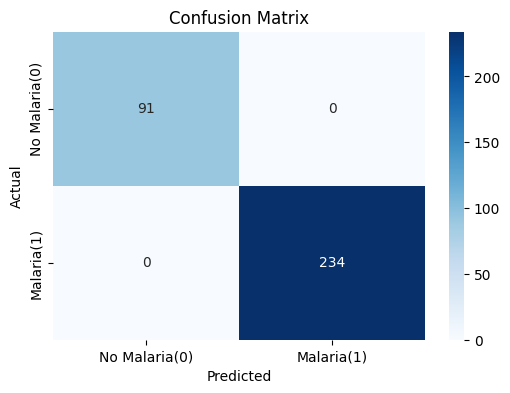

In [13]:
#Visualizations
#Confusion matrix
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No Malaria(0)','Malaria(1)'],yticklabels=['No Malaria(0)','Malaria(1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

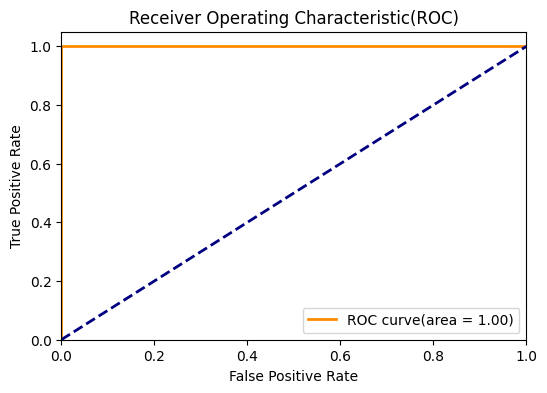

In [14]:
#ROC Curve
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,color='darkorange',lw=2,label=f'ROC curve(area = {roc_auc:.2f})')
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic(ROC)')
plt.legend(loc="lower right")
plt.show()
